In [1]:
# !pip3 install -r ../requirements.txt

In [2]:
import random
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.layers import Dense, Flatten, Input, Dropout, BatchNormalization
from keras.models import Sequential, Model
from keras.optimizers import Adam, SGD, RMSprop
from keras.applications import MobileNetV2
from keras.regularizers import l2

os.chdir('../') # move one level up to the base path
from src.utils import load_and_preprocess_images, data_augmentation # import the helper functions

In [3]:
repo_path = '/Users/hendriksippel/Documents/Repositories/cbs-mldl-drowsiness-detection'

syntheticDataPath = repo_path + '/data/synthetic'
syntheticTrainingPath = syntheticDataPath + '/TrainingSet/TrainingSet'
syntheticTestPath = syntheticDataPath + '/TestSet/TestSet'

realDataPath = repo_path + '/data/real'
realTrainingPath = realDataPath + '/TrainingSet'
realTestPath = realDataPath + '/TestSet'

In [4]:
# Hyperparameters
BATCH_SIZE = 32
IMAGE_SIZE = (224, 224)
INPUT_SHAPE = IMAGE_SIZE + (3,)

# set the random seeds to make sure that the results are reproducible
SEED = 1234
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
synth_train_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='training', validation_split=0.2)
synth_valid_data = load_and_preprocess_images(syntheticTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='validation', validation_split=0.2)
synth_test_data = load_and_preprocess_images(syntheticTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 1704 files belonging to 2 classes.
Using 1364 files for training.
Found 1704 files belonging to 2 classes.
Using 340 files for validation.
Found 4232 files belonging to 2 classes.


In [6]:
real_train_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='training', validation_split=0.2)
real_valid_data = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='validation', validation_split=0.2)
real_test_data = load_and_preprocess_images(realTestPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=False)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.
Using 775 files for validation.
Found 970 files belonging to 2 classes.


In [21]:
def initialize_model(mn_output_layer, unfreeze_from_layer, alpha, loss_function, optimizer, dropout_rate, regularization_rate, input_shape=INPUT_SHAPE):

    # Load the MobileNetV2 model    
    pretrained_model = MobileNetV2(
        input_shape=input_shape,
        alpha=alpha,
        include_top=False,
        weights='imagenet'
    )

    # Freeze the pretrained weights
    pretrained_model.trainable = False

    # Unfreeze the layers starting from unfreeze_from_layer (exclusive)
    unfreeze = False
    for layer in pretrained_model.layers:
        if unfreeze:
            layer.trainable = True
        elif layer.name == unfreeze_from_layer:
            layer.trainable = False
            unfreeze = True
        
    last_layer = pretrained_model.get_layer(mn_output_layer)
    base_model = Model(inputs=pretrained_model.input, outputs=last_layer.output)

    model = Sequential(name='baseline_model')
    model.add(Input(shape=input_shape))
    model.add(base_model)
    model.add(Flatten())

    model.add(Dense(256, activation='relu', kernel_regularizer=l2(regularization_rate)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(128, activation='relu', kernel_regularizer=l2(regularization_rate)))
    model.add(BatchNormalization())
    model.add(Dropout(dropout_rate))
    model.add(Dense(2, activation='softmax'))
    # model.add(Dense(1, activation='sigmoid'))

    model.compile(loss=loss_function, optimizer=optimizer, metrics=['accuracy'])

    return model

In [13]:
comment = "exp loss and optimizer"

model_file_path = repo_path + f"/models/baseline_model/ckpt/{comment}_checkpoint.model.keras"

early_stop = EarlyStopping(monitor="val_accuracy", mode="max", patience=15, start_from_epoch=10)
checkpoint = ModelCheckpoint(model_file_path, monitor="val_accuracy", mode="max", save_best_only=True, verbose=1)

MN_OUTPUT_LAYER = 'block_16_project_BN'
UNFREEZE_FROM_LAYER = 'block_16_project_BN'
EPOCHS = 30
ALPHA = 1.0
REGULARIZATION = 0.01
DROPOUT = 0.3
LEARNING_RATE = 0.0001

LOSS_FUNCTION = 'sparse_categorical_crossentropy' # needs to set the last layer to Dense(2, activation='softmax')
# LOSS_FUNCTION = 'binary_crossentropy' # need to set the last layer to Dense(1, activation='sigmoid')

OPTIMIZER = SGD(learning_rate=LEARNING_RATE)
# OPTIMIZER = Adam(learning_rate=LEARNING_RATE)
# OPTIMIZER = RMSprop(learning_rate=LEARNING_RATE)

model = initialize_model(mn_output_layer=MN_OUTPUT_LAYER, unfreeze_from_layer=UNFREEZE_FROM_LAYER, alpha=ALPHA, loss_function=LOSS_FUNCTION, optimizer=OPTIMIZER, dropout_rate=DROPOUT, regularization_rate=REGULARIZATION)

In [14]:
history = model.fit(
    real_train_data,
    validation_data=real_valid_data,
    epochs=EPOCHS,
    callbacks=[early_stop, checkpoint]
    )

Epoch 1/30


ValueError: Could not interpret loss identifier: focal_loss

In [24]:
loss_functions = [
    "sparse_categorical_crossentropy",
    # "binary_crossentropy"
]

optimizers = [
    SGD(learning_rate=LEARNING_RATE),
    # Adam(learning_rate=LEARNING_RATE),
    # RMSprop(learning_rate=LEARNING_RATE, momentum=0.9),
]

results = {}

for loss_function in loss_functions:
    for optimizer in optimizers:
        print(
            f"Training model with loss function {loss_function} and optimizer {optimizer.__class__.__name__}"
        )

        model = initialize_model(
            mn_output_layer=MN_OUTPUT_LAYER,
            unfreeze_from_layer=UNFREEZE_FROM_LAYER,
            alpha=ALPHA,
            loss_function=loss_function,
            optimizer=optimizer,
            dropout_rate=DROPOUT,
            regularization_rate=REGULARIZATION,
        )

        history = model.fit(
            real_train_data,
            validation_data=real_valid_data,
            epochs=EPOCHS,
            callbacks=[early_stop, checkpoint],
            verbose=1,
        )

        results[(loss_function, optimizer.__class__.__name__)] = {
            "history": history,
            "final_val_accuracy": history.history["val_accuracy"][-1],
        }

Training model with loss function sparse_categorical_crossentropy and optimizer SGD
Epoch 1/30
 8/97 ━━━━━━━━━━━━━━━━━━━━ 27s 304ms/step - accuracy: 0.4506 - loss: 8.1057

KeyboardInterrupt: 

Loss function: binary_crossentropy, Optimizer: SGD, Final validation accuracy: 0.9187096953392029


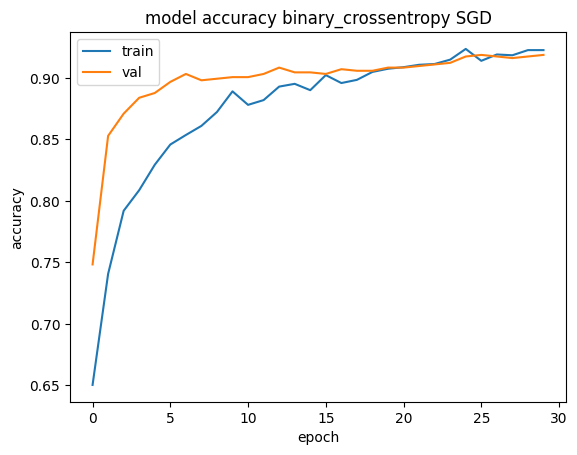

Loss function: binary_crossentropy, Optimizer: Adam, Final validation accuracy: 0.9187096953392029


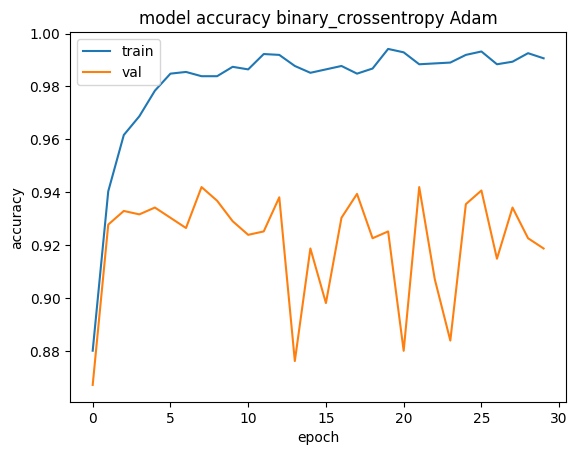

Loss function: binary_crossentropy, Optimizer: RMSprop, Final validation accuracy: 0.9148387312889099


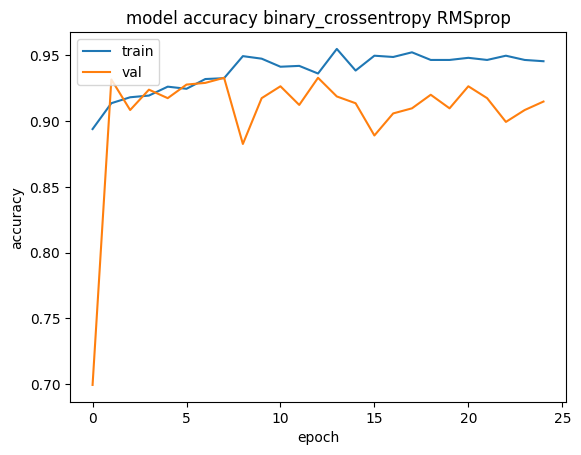

In [16]:
for key, value in results.items():
    print(f"Loss function: {key[0]}, Optimizer: {key[1]}, Final validation accuracy: {value['final_val_accuracy']}")
    # plot history for accuracy
    plt.plot(value['history'].history['accuracy'])
    plt.plot(value['history'].history['val_accuracy'])
    plt.title(f'model accuracy {key[0]} {key[1]}')
    plt.ylabel('accuracy')
    plt.xlabel('epoch')
    plt.legend(['train', 'val'], loc='upper left')
    plt.show()

In [9]:
model.summary(show_trainable=True)

Model: "baseline_model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ functional_1 (Functional)   │ (None, 7, 7, 320)     │  1,843,264 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ flatten (Flatten)           │ (None, 15680)         │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 256)           │  4,014,336 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization         │ (None, 256)           │      1,024 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 256)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_1 (Dense)             │ (None, 128)           │     32,896 │   Y   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ batch_normalization_1       │ (None, 128)           │        512 │   Y   │
│ (BatchNormalization)        │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout_1 (Dropout)         │ (None, 128)           │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense_2 (Dense)             │ (None, 2)             │        258 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 5,892,290 (22.48 MB)

 Trainable params: 4,048,258 (15.44 MB)

 Non-trainable params: 1,844,032 (7.03 MB)

NameError: name 'history' is not defined

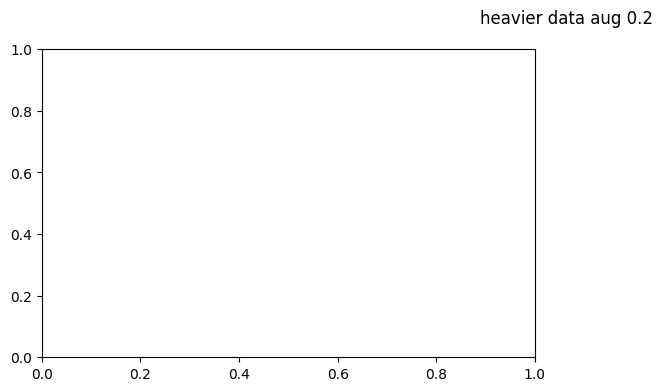

In [ ]:
# plot accuracy and loss
plt.figure(figsize=(14, 4))

# plot headline
plt.suptitle(comment)

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

# get the best val_accuracy and val_loss
best_train_accuracy = np.max(history.history['accuracy']).round(4)
best_train_loss = np.min(history.history['loss']).round(4)
best_val_accuracy = np.max(history.history['val_accuracy']).round(4)
best_val_loss = np.min(history.history['val_loss']).round(4)

print(f'Best train_accuracy: {best_train_accuracy}')
print(f'Best train_loss: {best_train_loss}')
print(f'Best val_accuracy: {best_val_accuracy}')
print(f'Best val_loss: {best_val_loss}')

In [ ]:
# load the best model
model.load_weights(model_file_path)

Found 3876 files belonging to 2 classes.
Using 3101 files for training.
Found 3876 files belonging to 2 classes.


2024-07-08 17:47:55.813474: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-07-08 17:47:56.125249: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
2024-07-08 17:47:56.261594: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.

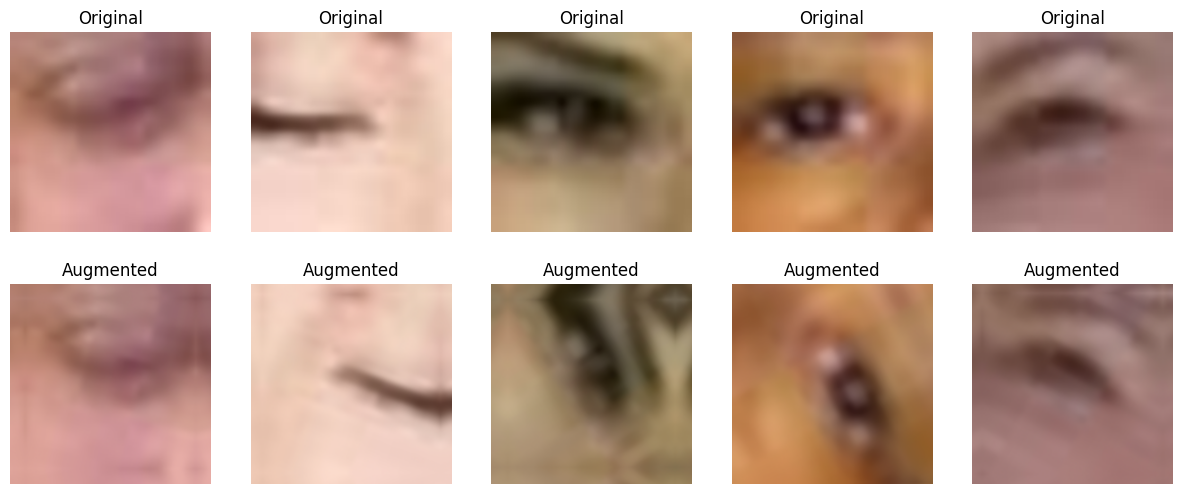

In [17]:
real_train_data_augm = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='training', validation_split=0.2, skip_preprocessing=True)
real_train_data_orig = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, skip_preprocessing=True)

def plot_images(img_orig, img_augm, num_images=5):
    plt.figure(figsize=(15, 6))
    images_displayed = 0

    # Take one batch from each dataset
    for (images1, _), (images2, _) in zip(img_orig.take(1), img_augm.take(1)):
        for i in range(num_images):
            if images_displayed >= num_images:
                break

            # Plot original image
            plt.subplot(2, num_images, images_displayed + 1)
            plt.imshow(images1[i].numpy().astype("uint8"))
            plt.title(f"Original")
            plt.axis("off")

            # Plot augmented image
            plt.subplot(2, num_images, images_displayed + num_images + 1)
            plt.imshow(images2[i].numpy().astype("uint8"))
            plt.title(f"Augmented")
            plt.axis("off")

            images_displayed += 1

# Plotting original and augmented images
plot_images(img_orig=real_train_data_orig, img_augm=real_train_data_augm)

Found 3876 files belonging to 2 classes.
Using 775 files for validation.


2024-07-08 13:59:15.350640: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.
2024-07-08 13:59:15.358013: W tensorflow/core/kernels/data/cache_dataset_ops.cc:858] The calling iterator did not fully read the dataset being cached. In order to avoid unexpected truncation of the dataset, the partially cached contents of the dataset  will be discarded. This can happen if you have an input pipeline similar to `dataset.cache().take(k).repeat()`. You should use `dataset.take(k).cache().repeat()` instead.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 361ms/step


2024-07-08 13:59:15.763070: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


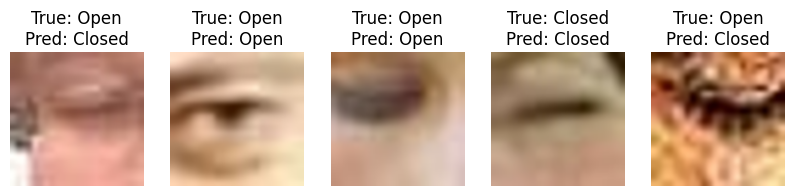

In [ ]:
real_valid_data_skip_preprocessing = load_and_preprocess_images(realTrainingPath, batch_size=BATCH_SIZE, image_size=IMAGE_SIZE, seed=SEED, shuffle=True, subset='validation', validation_split=0.2, skip_preprocessing=True)

def plot_predictions(model, dataset, dataset_visual, class_names = ["Closed", "Open"], num_images=5):
    plt.figure(figsize=(10, 5))
    images_displayed = 0

    for (images, labels), (images_visual, _) in zip(dataset.take(1), dataset_visual.take(1)):
        predictions = model.predict(images)
        predicted_labels = tf.argmax(predictions, axis=1)

        for i in range(len(images)):
            if images_displayed >= num_images:
                break

            plt.subplot(1, num_images, images_displayed + 1)
            plt.imshow(images_visual[i].numpy().astype("uint8"))
            plt.title(f"True: {class_names[labels[i]]}\nPred: {class_names[predicted_labels[i]]}")
            plt.axis("off")
            images_displayed += 1

# Plotting predictions from validation data
plot_predictions(model, real_valid_data, real_valid_data_skip_preprocessing)

In [ ]:
mn_test =  MobileNetV2(
        input_shape=INPUT_SHAPE,
        alpha=ALPHA,
        include_top=False,
        weights='imagenet'
    )

mn_test.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_3[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 2,223,872 (8.48 MB)

 Non-trainable params: 34,112 (133.25 KB)